In [51]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.estimators import K2, BIC, BDeu
from pgmpy.causal_discovery import HillClimbSearch
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import networkx as nx
import daft
import shapefile
np.set_printoptions(threshold=1000)

In [52]:
Single_Subject_UOF = pd.read_csv('TRI_SingleSubject_AnyMembers.csv')
Single_Subject_UOF.head()

,TRI Incident Number,ForceType,Occurrence Date,Incident Pct,Patrol Borough,YearMonthShort,BasisForEncounter,Subject Injury Level,Subject Injured,Age,Subject Race,Subject Gender,Force Against MOS,Subject Used Force,MemberCount
0,2024032962162,Physical Force,08/31/2024,13,PBMS,2024 Aug,CRIME/VIOLATION IN PROGRESS,No Injury,N,17.0,BLACK,MALE,Physical Force,Y,2
1,2024033962356,Physical Force,08/31/2024,14,PBMS,2024 Aug,CRIME/VIOLATION IN PROGRESS,No Injury,N,30.0,BLACK,MALE,Physical Force,Y,2
2,2024090962120,Physical Force,08/31/2024,71,PBBS,2024 Aug,CRIME/VIOLATION IN PROGRESS,No Injury,N,19.0,OTHER,MALE,Physical Force,Y,2
3,2024096962122,Physical Force,08/31/2024,77,PBBN,2024 Aug,CRIME/VIOLATION IN PROGRESS,No Injury,N,38.0,BLACK,MALE,Physical Force,Y,2
4,2024081962083,Physical Force,08/31/2024,62,PBBS,2024 Aug,CRIME/VIOLATION IN PROGRESS,Physical Injury,Y,17.0,HISPANIC,MALE,Physical Force,Y,2


In [53]:
incidents = Single_Subject_UOF.dropna()
data = incidents.drop(['TRI Incident Number', 'YearMonthShort', 'Occurrence Date', 'Subject Injury Level', 'ForceType'], axis=1)
data['Incident Pct'] = data['Incident Pct'].astype(str)
train,test=train_test_split(data,random_state=2,test_size=0.3)
display(train.head())

hc = HillClimbSearch(scoring_method='bic-d', return_type='dag')
best_net = hc.fit(data)
print(best_net.causal_graph_.edges)

,Incident Pct,Patrol Borough,BasisForEncounter,Subject Injured,Age,Subject Race,Subject Gender,Force Against MOS,Subject Used Force,MemberCount
28218,7,PBMS,PERSON IN CRISIS,Y,21.0,BLACK,FEMALE,Physical Force,Y,0
47095,52,PBBX,PERSON IN CRISIS,Y,51.0,HISPANIC,MALE,Physical Force,Y,4
31700,120,PBSI,PERSON IN CRISIS,N,46.0,OTHER,MALE,Physical Force,Y,1
30655,110,PBQN,VTL INFRACTION,N,25.0,OTHER,UNK,No Force,N,1
29127,123,PBSI,ORDER OF PROTECTION,Y,33.0,WHITE,FEMALE,No Force,N,1


  0%|          | 9/1000000 [00:00<16:46:21, 16.56it/s]

[('Incident Pct', 'Patrol Borough'), ('Incident Pct', 'Subject Race'), ('Subject Injured', 'Force Against MOS'), ('Subject Race', 'Subject Gender'), ('Subject Gender', 'BasisForEncounter'), ('Subject Gender', 'Subject Injured'), ('Subject Used Force', 'Force Against MOS'), ('Subject Used Force', 'Subject Gender'), ('MemberCount', 'Subject Used Force')]


+---------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+
| Subject Injured                       | Subject Injured(N)    | Subject Injured(N)    | Subject Injured(Y)    | Subject Injured(Y)    |
+---------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+
| Subject Used Force                    | Subject Used Force(N) | Subject Used Force(Y) | Subject Used Force(N) | Subject Used Force(Y) |
+---------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+
| Force Against MOS(Cutting Instrument) | 0.0                   | 0.0010363205684958546 | 0.0                   | 0.0020572450805008947 |
+---------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+
| Force Against MOS(Displayed Weap

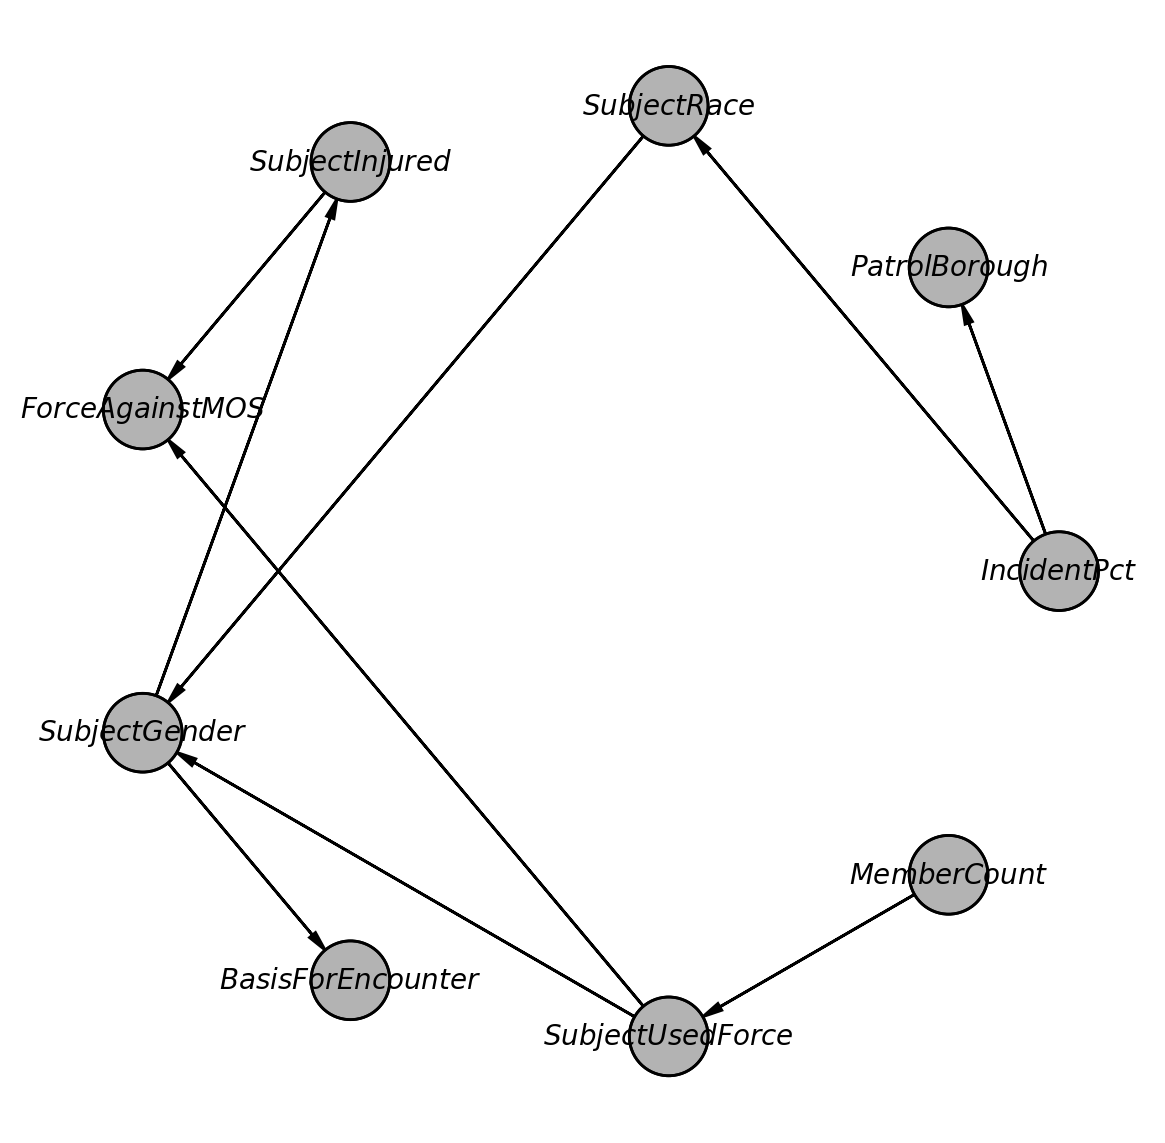

In [54]:
best_model = DiscreteBayesianNetwork(best_net.causal_graph_.edges)
best_model.fit(train, estimator=MaximumLikelihoodEstimator)
#graph = best_model.to_graphviz()
daft_graph = best_model.to_daft(node_pos="circular", pgm_params={'grid_unit': 6, 'node_unit': 1,  'dpi': 200}, node_params={'plot_params': {'facecolor': 'blue'}})
daft_graph.render()

def print_full(cpd):
    backup = TabularCPD._truncate_strtable
    TabularCPD._truncate_strtable = lambda self, x: x
    print(cpd)
    TabularCPD._truncate_strtable = backup

print_full(best_model.get_cpds()[4])
# for cpd in best_model.get_cpds():
#     print("CPD of {variable}:".format(variable=cpd.variable))
#     print(cpd)

In [55]:
train_x = train.copy()
node_cols = list(best_model.nodes.keys())
train_x = train_x[node_cols].drop('Subject Injured', axis=1)
predicted_train = best_model.predict(train_x)
print('done predicting')
print("In sample:",(train.loc[:,'Subject Injured'].sort_index()==predicted_train['Subject Injured'].sort_index()).mean())

100%|██████████| 12545/12545 [00:28<00:00, 439.50it/s]


done predicting
In sample: 0.6462717850067472


In [56]:
test_x = test.copy()
test_x = test_x[node_cols].drop('Subject Injured', axis=1)
predicted_test = best_model.predict(test_x)
print("Out of sample:",(test.loc[:,'Subject Injured'].sort_index()==predicted_test['Subject Injured'].sort_index()).mean())

100%|██████████| 7306/7306 [00:16<00:00, 440.37it/s]


Out of sample: 0.642416934619507
